# Extract Climate Data — Jablje

Extracts daily point timeseries from EURO-CORDEX NetCDF files for Jablje and summarises statistics by 30-year period.

NetCDF source files (historical, rcp26, rcp45, rcp85) are in . Outputs go to .

In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
from aquacrop_slovenia import config
from aquacrop_slovenia.climate_data import extract_all_timeseries
from aquacrop_slovenia.plots import load_all_timeseries, plot_all_timeseries, plot_grid_points, plot_all_period_statistics
from aquacrop_slovenia.climate_data import prepare_climate_data
from IPython.display import display
from loguru import logger
import calendar
import pandas as pd
import sys

logger.add(sys.stdout, colorize=True)

2

## Jablje

In [7]:
LOCATION_NAME = "jablje"
TARGET_LAT = 46.144
TARGET_LON = 14.557
STATION_LAT = 46.211  # Letališče Jožeta Pučnika Ljubljana (ARSO station 8)
STATION_LON = 14.478

2026-08-10 16:33:13.456 | INFO     | aquacrop_slovenia.plots:plot_grid_points:78 - Nearest grid cell: lat=46.1875, lon=14.5625


2026-08-10 16:33:13.456 | INFO     | aquacrop_slovenia.plots:plot_grid_points:78 - Nearest grid cell: lat=46.1875, lon=14.5625
2026-08-10 16:33:13.456 | INFO     | aquacrop_slovenia.plots:plot_grid_points:78 - Nearest grid cell: lat=46.1875, lon=14.5625


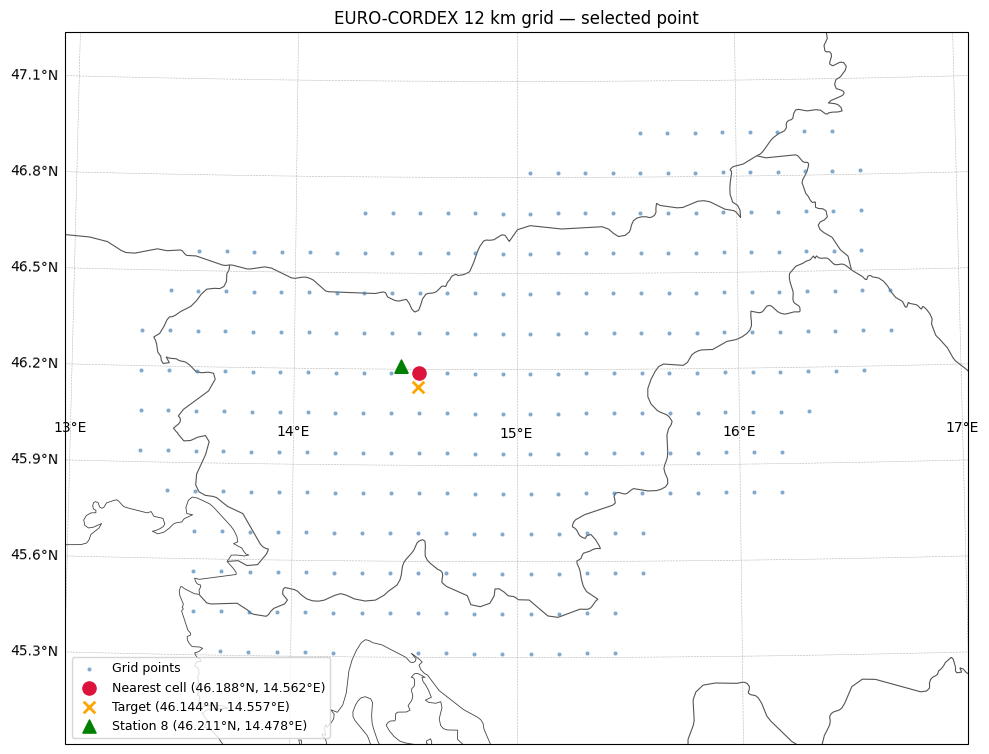

In [8]:
fig = plot_grid_points(TARGET_LAT, TARGET_LON, station_lat=STATION_LAT, station_lon=STATION_LON, station_label="Station 8")
fig.tight_layout()

In [9]:
extract_all_timeseries(TARGET_LAT, TARGET_LON, location_name=LOCATION_NAME)
print(f"CSVs written to: {config.INTERIM_CLIMATE_DIR}")

Extracting timeseries:   0%|          | 0/15 [00:00<?, ?it/s]Processing obs (ARSO / obs) / hist
Nearest cell: lat=46.1875, lon=14.5625 (target: 46.1440, 14.5570)
Extracting timeseries:   7%|▋         | 1/15 [00:00<00:05,  2.46it/s]Processing model2 (ICHEC-EC-EARTH / DMI-HIRHAM5) / rcp26
Nearest cell: lat=46.1875, lon=14.5625 (target: 46.1440, 14.5570)
Extracting timeseries:  13%|█▎        | 2/15 [00:02<00:14,  1.14s/it]Processing model4 (MOHC-HadGEM2-ES / KNMI-RACMO22E) / rcp26
Nearest cell: lat=46.1875, lon=14.5625 (target: 46.1440, 14.5570)
Extracting timeseries:  20%|██        | 3/15 [00:03<00:16,  1.36s/it]Processing model1 (CNRM-CERFACS-CNRM-CM5 / CLMcom-CCLM4-8-17) / rcp45
Nearest cell: lat=46.1875, lon=14.5625 (target: 46.1440, 14.5570)
Extracting timeseries:  27%|██▋       | 4/15 [00:05<00:16,  1.48s/it]Processing model2 (ICHEC-EC-EARTH / DMI-HIRHAM5) / rcp45
Nearest cell: lat=46.1875, lon=14.5625 (target: 46.1440, 14.5570)
Extracting timeseries:  33%|███▎      | 5/15 [00:07<00

## Preparing data for aquacrop

Loads the interim files and prepare the data so it has correct units and form to be used when calling Aquacrop. The data is then saved in the processed folder in pickle files.

In [10]:
prepare_climate_data(LOCATION_NAME)
print(f"Pickles written to: {config.PROCESSED_CLIMATE_DIR}")

Preparing climate data for jablje with model1 and rcp45
Saved jablje_model1_rcp45.pkl
Preparing climate data for jablje with model1 and rcp85
Saved jablje_model1_rcp85.pkl
Preparing climate data for jablje with model2 and rcp26
Saved jablje_model2_rcp26.pkl
Preparing climate data for jablje with model2 and rcp45
Saved jablje_model2_rcp45.pkl
Preparing climate data for jablje with model2 and rcp85
Saved jablje_model2_rcp85.pkl
Preparing climate data for jablje with model3 and rcp45
Saved jablje_model3_rcp45.pkl
Preparing climate data for jablje with model3 and rcp85
Saved jablje_model3_rcp85.pkl
Preparing climate data for jablje with model4 and rcp26
Saved jablje_model4_rcp26.pkl
Preparing climate data for jablje with model4 and rcp45
Saved jablje_model4_rcp45.pkl
Preparing climate data for jablje with model4 and rcp85
Saved jablje_model4_rcp85.pkl
Preparing climate data for jablje with model5 and rcp45
Saved jablje_model5_rcp45.pkl
Preparing climate data for jablje with model5 and rcp8

## Model mapping ids

In [11]:
# Model mapping table
mapping = pd.read_csv(config.INTERIM_CLIMATE_DIR / "model_mapping.csv")
display(mapping)

sample = pd.read_csv(
    config.INTERIM_CLIMATE_DIR / f"{LOCATION_NAME}_obs_hist.csv", index_col=0, parse_dates=True
)
sample.head()

,short_name,gcm,rcm
0,obs,ARSO,NaN
1,model1,CNRM-CERFACS-CNRM-CM5,CLMcom-CCLM4-8-17
2,model2,ICHEC-EC-EARTH,DMI-HIRHAM5
3,model3,IPSL-IPSL-CM5A-MR,IPSL-INERIS-WRF331F
4,model4,MOHC-HadGEM2-ES,KNMI-RACMO22E
5,model5,MPI-M-MPI-ESM-LR,CLMcom-CCLM4-8-17
6,model6,MPI-M-MPI-ESM-LR,SMHI-RCA4


,pr,tas,tasmax,tasmin,evspsblpot
time,,,,,
1981-01-01,0.000000,269.77618,273.58950,264.14432,0.000002
1981-01-02,0.000000,273.40155,278.70483,267.88170,0.000004
1981-01-03,0.000000,276.67004,279.51318,269.33743,0.000009
1981-01-04,0.000000,275.73843,278.75370,273.53850,0.000003
1981-01-05,0.000082,273.91550,277.81406,271.70580,0.000011


In [12]:
sample.describe()

,pr,tas,tasmax,tasmin,evspsblpot
count,10957.000000,10957.000000,10957.000000,10957.000000,10957.000000
mean,0.000042,282.742468,288.280631,277.910012,0.000023
std,0.000098,8.204210,9.356501,7.561026,0.000018
min,0.000000,254.739670,261.295870,249.158550,0.000000
25%,0.000000,275.980740,280.585540,272.205630,0.000007
50%,0.000001,283.404420,288.808870,278.489000,0.000018
75%,0.000030,289.573030,296.018860,284.256870,0.000037
max,0.001758,300.337100,310.298900,293.747440,0.000081


In [14]:
df = load_all_timeseries(LOCATION_NAME)
print(df.columns.get_level_values("model").unique().tolist())
df.head()

Loaded 15 timeseries files for 'jablje'
['model1', 'model2', 'model3', 'model4', 'model5', 'model6', 'obs']


model         model1                                                        \
scenario       rcp45                                                 rcp85   
variable          pr     tas     tasmax     tasmin    evspsblpot        pr   
date                                                                         
1981-01-01  0.000002  276.53  279.76685  273.63684  5.082500e-06  0.000002   
1981-01-02  0.000026  276.37  277.15120  275.90120  4.265200e-06  0.000025   
1981-01-03  0.000152  272.51  275.65850  267.05850  2.511800e-06  0.000163   
1981-01-04  0.000000  267.29  273.64820  262.17820  7.248900e-07  0.000000   
1981-01-05  0.000000  268.38  275.93005  264.61005  2.355100e-06  0.000000   

model                                                   ...    model6          \
scenario                                                ...     rcp85           
variable       tas     tasmax     tasmin    evspsblpot  ...        pr     tas   
date                                                    ...                     
1981-01-01  275.85  279.13684  272.98685  4.592600e-06  ...  0.000000  266.13   
1981-01-02  275.69  276.33124  275.44122  3.988500e-06  ...  0.000000  267.49   
1981-01-03  272.94  275.99850  267.47852  2.471600e-06  ...  0.000000  269.29   
1981-01-04  267.30  273.93817  262.05817  6.918900e-07  ...  0.000001  271.30   
1981-01-05  268.45  276.11008  264.55008  2.356900e-06  ...  0.000000  271.28   

model                                             obs                        \
scenario                                         hist                         
variable       tasmax     tasmin evspsblpot        pr        tas     tasmax   
date                                                                          
1981-01-01  267.83750  264.71747   0.000009  0.000000  269.77618  273.58950   
1981-01-02  270.16050  263.16050   0.000005  0.000000  273.40155  278.70483   
1981-01-03  273.14682  267.19680   0.000005  0.000000  276.67004  279.51318   
1981-01-04  277.47394  266.79395   0.000007  0.000000  275.73843  278.75370   
1981-01-05  274.53973  268.14972   0.000004  0.000082  273.91550  277.81406   

model                             
scenario                          
variable       tasmin evspsblpot  
date                              
1981-01-01  264.14432   0.000002  
1981-01-02  267.88170   0.000004  
1981-01-03  269.33743   0.000009  
1981-01-04  273.53850   0.000003  
1981-01-05  271.70580   0.000011  

[5 rows x 75 columns]

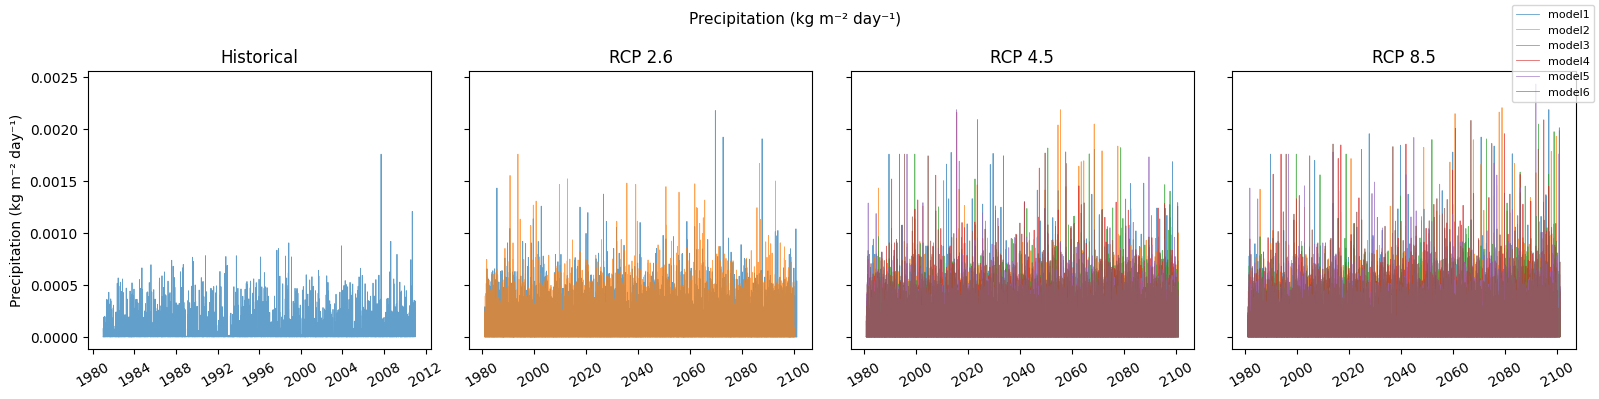

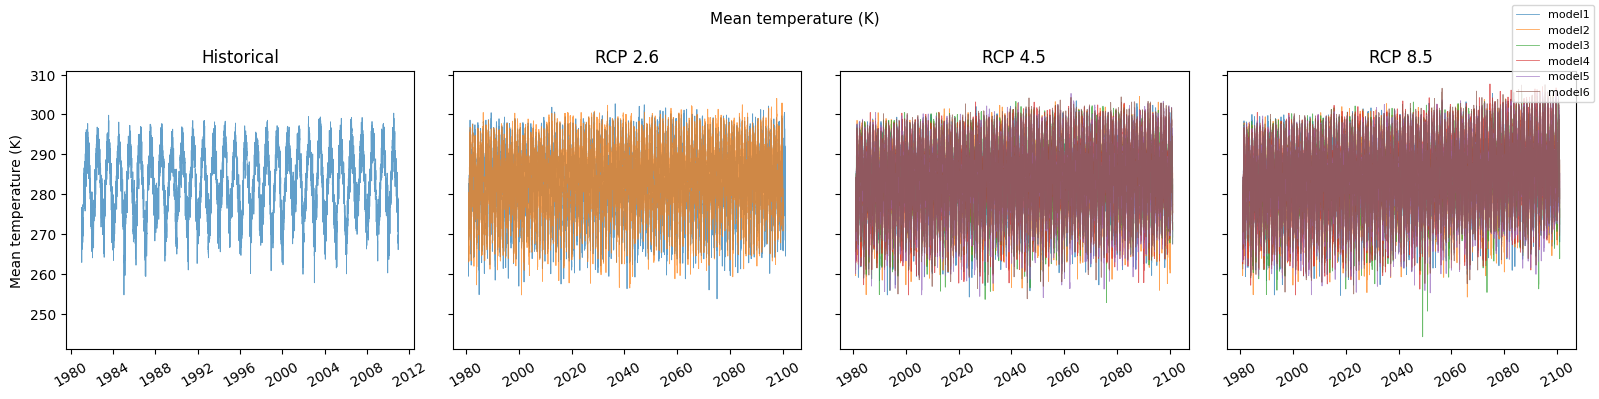

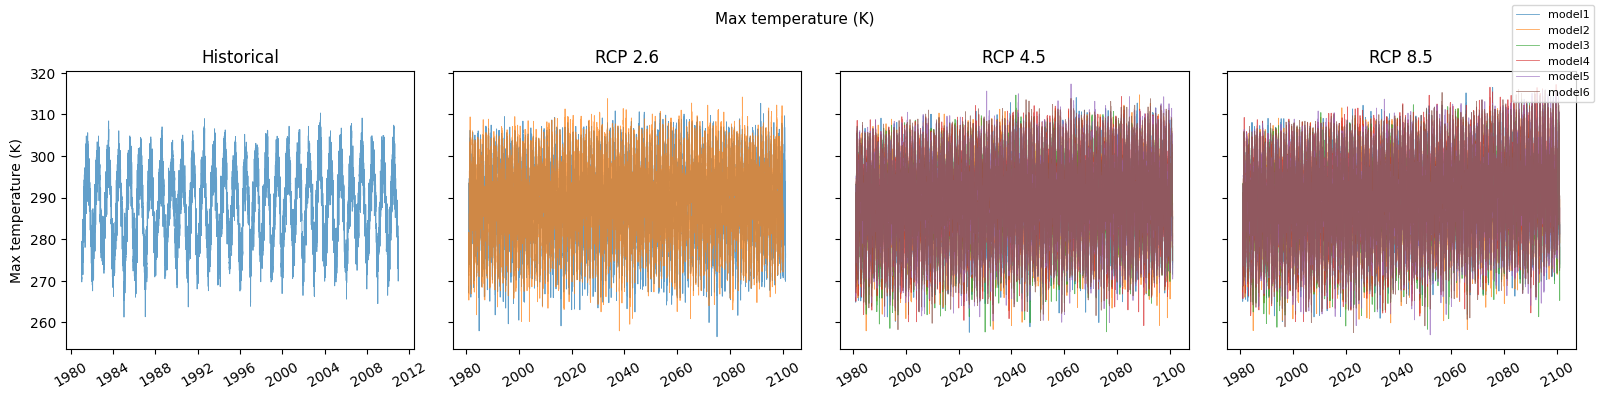

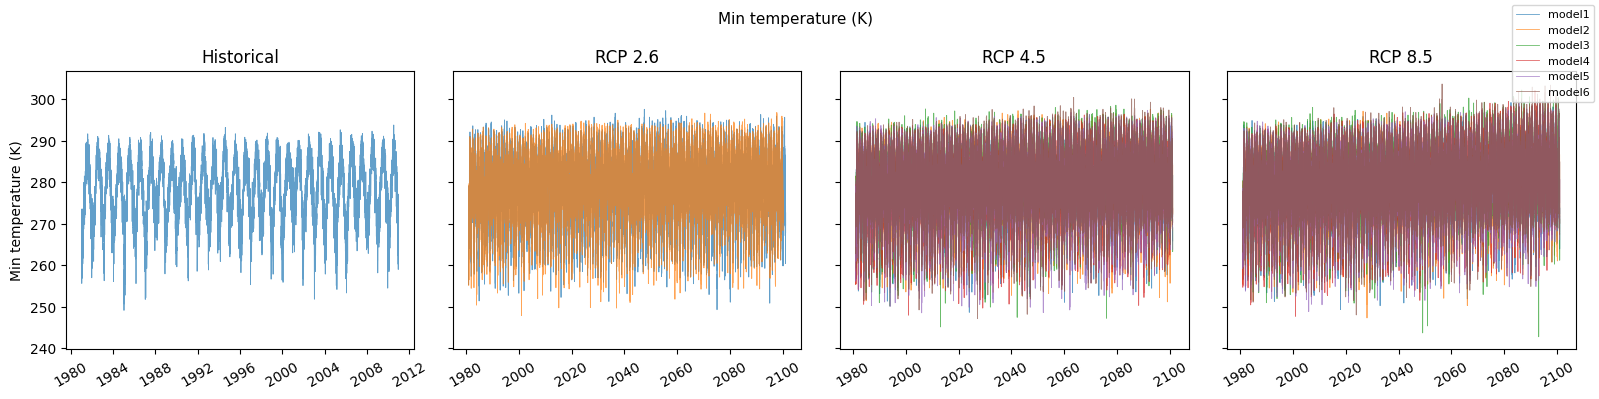

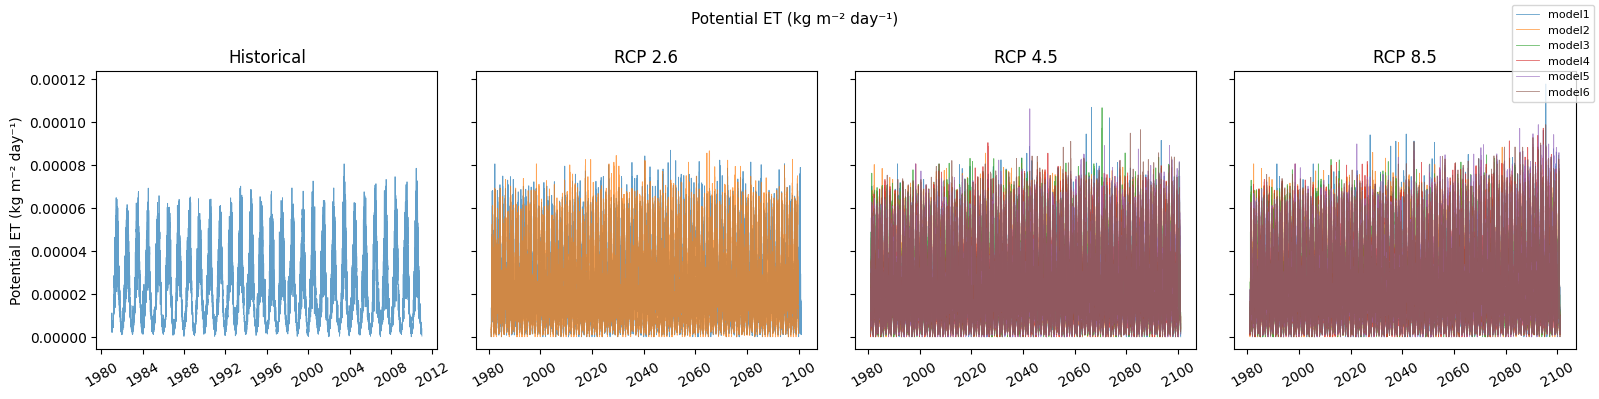

In [15]:
figs = plot_all_timeseries(df)

## Statistics

Monthly climatology and yearly summary statistics (mean, min, max) for each variable, model and scenario, split into 30-year periods. Temperatures converted to °C.

In [16]:
MONTH_ABBR = [calendar.month_abbr[m] for m in range(1, 13)]

PERIODS = ["1981-2010", "2011-2040", "2041-2070", "2071-2100"]
_PERIOD_BINS = [1980, 2010, 2040, 2070, 2100]
TEMP_VARS = {"tas", "tasmax", "tasmin"}

long = df.stack(level=["model", "scenario"]).copy()
for var in TEMP_VARS:
    if var in long.columns:
        long.loc[:, var] -= 273.15

date_idx = long.index.get_level_values("date")
model_idx = long.index.get_level_values("model")
scen_idx = long.index.get_level_values("scenario")
period_cat = pd.cut(date_idx.year, bins=_PERIOD_BINS, labels=PERIODS)

monthly_clim = long.groupby([period_cat, scen_idx, model_idx, date_idx.month]).mean()
monthly_clim.index.names = ["period", "scenario", "model", "month"]
monthly_clim = monthly_clim.rename(
    index={i: MONTH_ABBR[i - 1] for i in range(1, 13)}, level="month"
)

yearly = long.groupby([period_cat, scen_idx, model_idx, date_idx.year]).mean()
yearly.index.names = ["period", "scenario", "model", "year"]
yearly_summary = yearly.groupby(level=["period", "scenario", "model"]).agg(["mean", "min", "max"])

print(f"Monthly climatology shape: {monthly_clim.shape}")
print(f"Yearly summary shape:      {yearly_summary.shape}")

C:\Users\rokku\AppData\Local\Temp\ipykernel_66936\3331141006.py:7: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = df.stack(level=["model", "scenario"]).copy()


Monthly climatology shape: (1344, 5)
Yearly summary shape:      (112, 15)


C:\Users\rokku\AppData\Local\Temp\ipykernel_66936\3331141006.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_clim = long.groupby([period_cat, scen_idx, model_idx, date_idx.month]).mean()
C:\Users\rokku\AppData\Local\Temp\ipykernel_66936\3331141006.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  yearly = long.groupby([period_cat, scen_idx, model_idx, date_idx.year]).mean()
C:\Users\rokku\AppData\Local\Temp\ipykernel_66936\3331141006.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current

In [17]:
VARIABLE_LABELS = {
    "pr": "Precipitation (kg m⁻² day⁻¹)",
    "tas": "Mean temperature (°C)",
    "tasmax": "Max temperature (°C)",
    "tasmin": "Min temperature (°C)",
    "evspsblpot": "Potential ET (kg m⁻² day⁻¹)",
}
_caption_style = [{"selector": "caption", "props": "font-weight: bold; font-size: 1.1em; text-align: left;"}]
_month_order = {m: i for i, m in enumerate(MONTH_ABBR)}

#print("=== Monthly Climatology ===")
#for var in monthly_clim.columns:
#    tbl = monthly_clim[var].unstack("period")
#    tbl = tbl.reorder_levels(["month", "model", "scenario"])
#    tbl = tbl.sort_index(level="month", sort_remaining=False,
#                         key=lambda idx: idx.map(_month_order))
#    display(tbl.style.format("{:.4g}").set_caption(VARIABLE_LABELS.get(var, var)).set_table_styles(_caption_style))

In [18]:
#print("=== Yearly Statistics (mean / min / max of annual means) ===")
#for var in yearly_summary.columns.get_level_values(0).unique():
#    display(
#        yearly_summary[var].style
#        .format("{:.5g}")
#        .set_caption(VARIABLE_LABELS.get(var, var))
#        .set_table_styles(_caption_style)
#    )

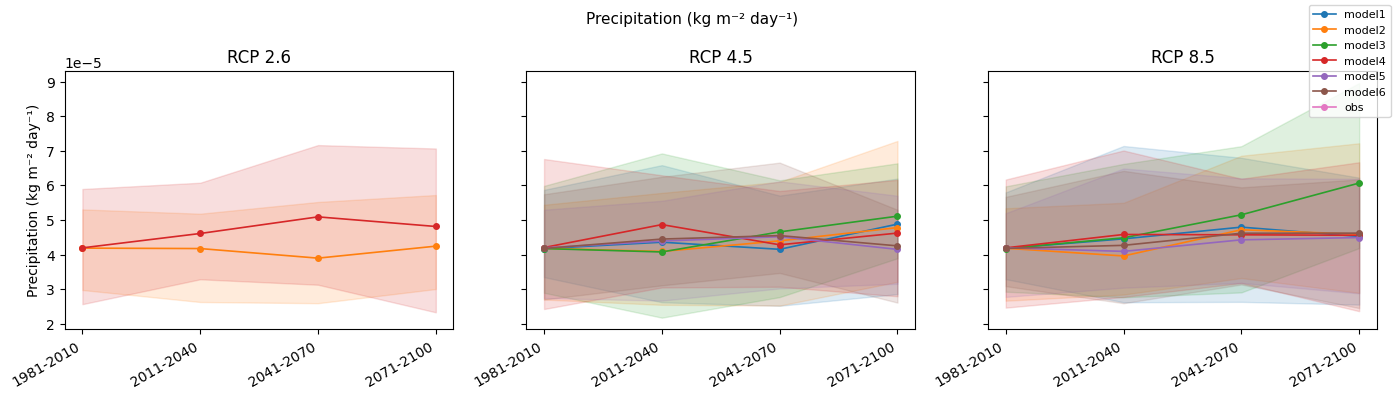

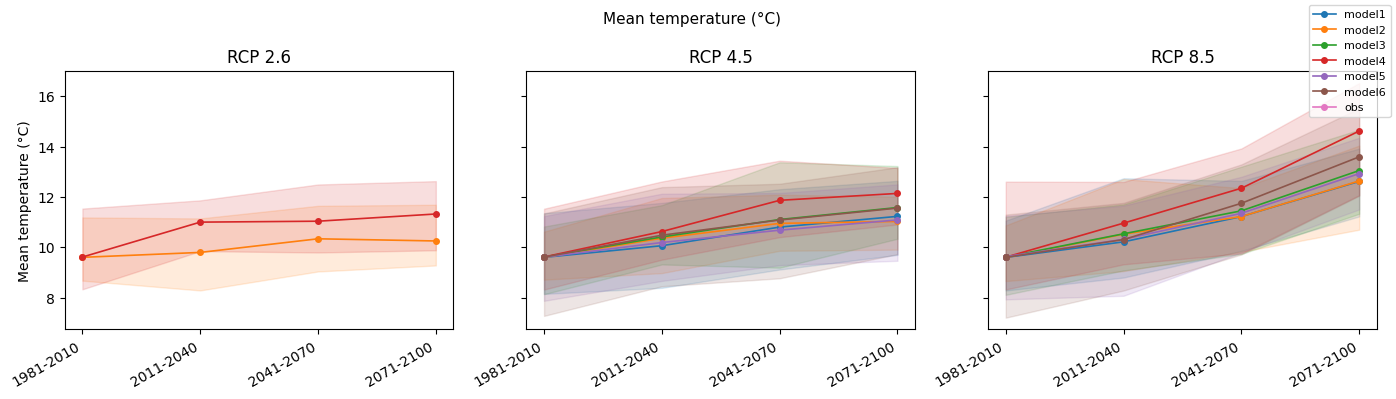

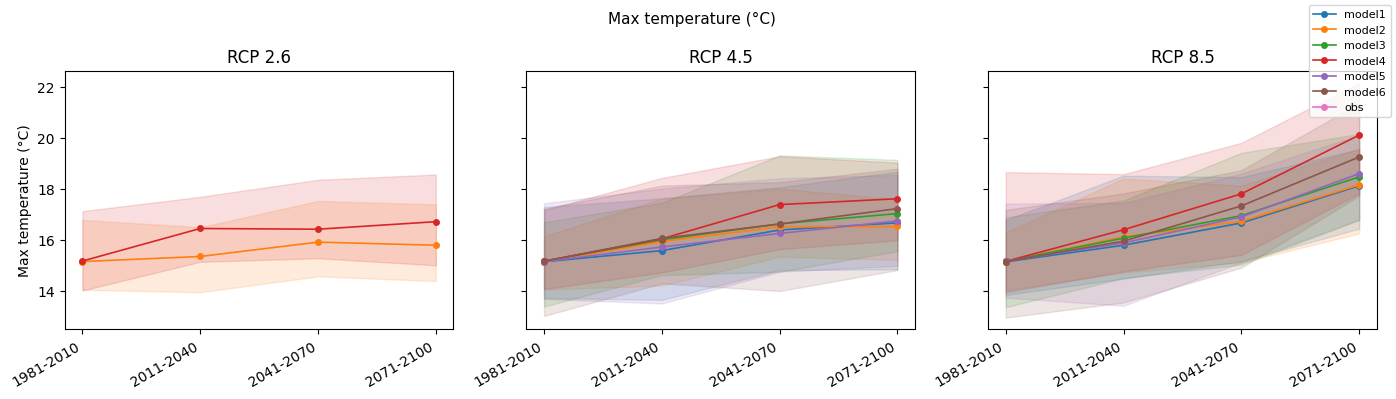

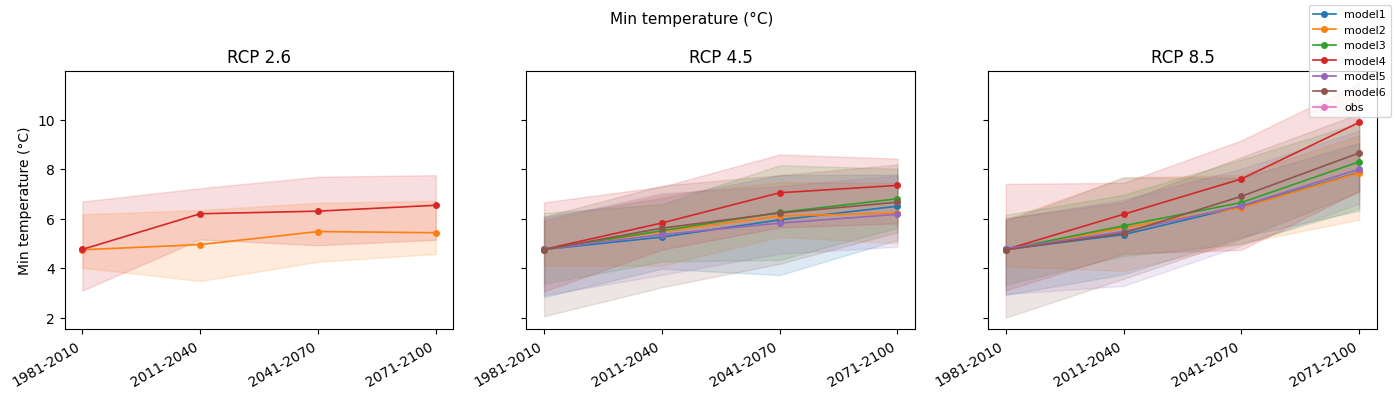

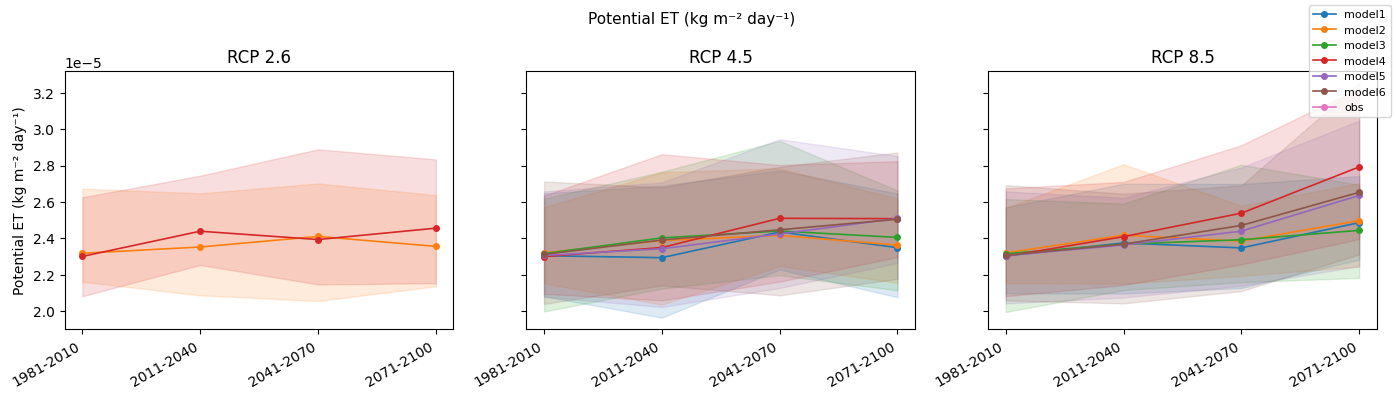

In [19]:
figs = plot_all_period_statistics(yearly_summary)

## Comparison with weather station (Station 8)
Monthly climatology for the overlapping period (1993–2010) comparing all RCM historical runs against the station record. Temperature in °C; precipitation and ETo in mm/day."

In [20]:
import matplotlib.pyplot as plt
import numpy as np

STATION_ID = 8
OVERLAP_START = "1993"
OVERLAP_END   = "2010"

# --- Station data ---
station_raw = pd.read_pickle(config.PROCESSED_WEATHER_DIR / f"station_{STATION_ID}.pkl")
station_raw = station_raw.set_index("datum")
station_raw.index = pd.to_datetime(station_raw.index)
station_hist = station_raw.loc[OVERLAP_START:OVERLAP_END]

station_monthly = station_hist.groupby(station_hist.index.month).mean()[["tpov", "tmin", "tmax", "pad", "etp"]]
station_monthly.index = MONTH_ABBR

# --- Climate data (long already has temps in °C, pr/evspsblpot still in kg m⁻² s⁻¹) ---
climate_hist = long.loc[OVERLAP_START:OVERLAP_END].copy()
climate_hist.loc[:, "pr"]         = climate_hist["pr"]         * 86400  # → mm/day
climate_hist.loc[:, "evspsblpot"] = climate_hist["evspsblpot"] * 86400  # → mm/day

climate_monthly = (
    climate_hist
    .groupby([
        climate_hist.index.get_level_values("model"),
        climate_hist.index.get_level_values("scenario"),
        climate_hist.index.get_level_values("date").month,
    ])
    .mean()
)
climate_monthly.index.names = ["model", "scenario", "month"]
climate_monthly = climate_monthly.rename(index={i: MONTH_ABBR[i-1] for i in range(1, 13)}, level="month")

print(f"Station months: {len(station_monthly)}  |  Climate months: {len(climate_monthly)}")
station_monthly.round(2)

Station months: 12  |  Climate months: 180


,tpov,tmin,tmax,pad,etp
Jan,-1.51,-5.26,2.86,2.07,0.32
Feb,0.08,-5.06,6.41,2.10,0.69
Mar,4.25,-1.51,10.92,2.57,1.41
Apr,9.07,2.83,15.76,3.18,2.28
May,14.51,7.58,21.37,3.22,3.39
Jun,18.14,11.55,24.48,4.27,3.97
Jul,19.33,12.58,26.43,4.30,4.11
Aug,18.67,12.72,25.75,4.55,3.40
Sep,13.63,8.56,20.35,5.11,2.04
Oct,9.40,5.11,15.42,4.15,1.07


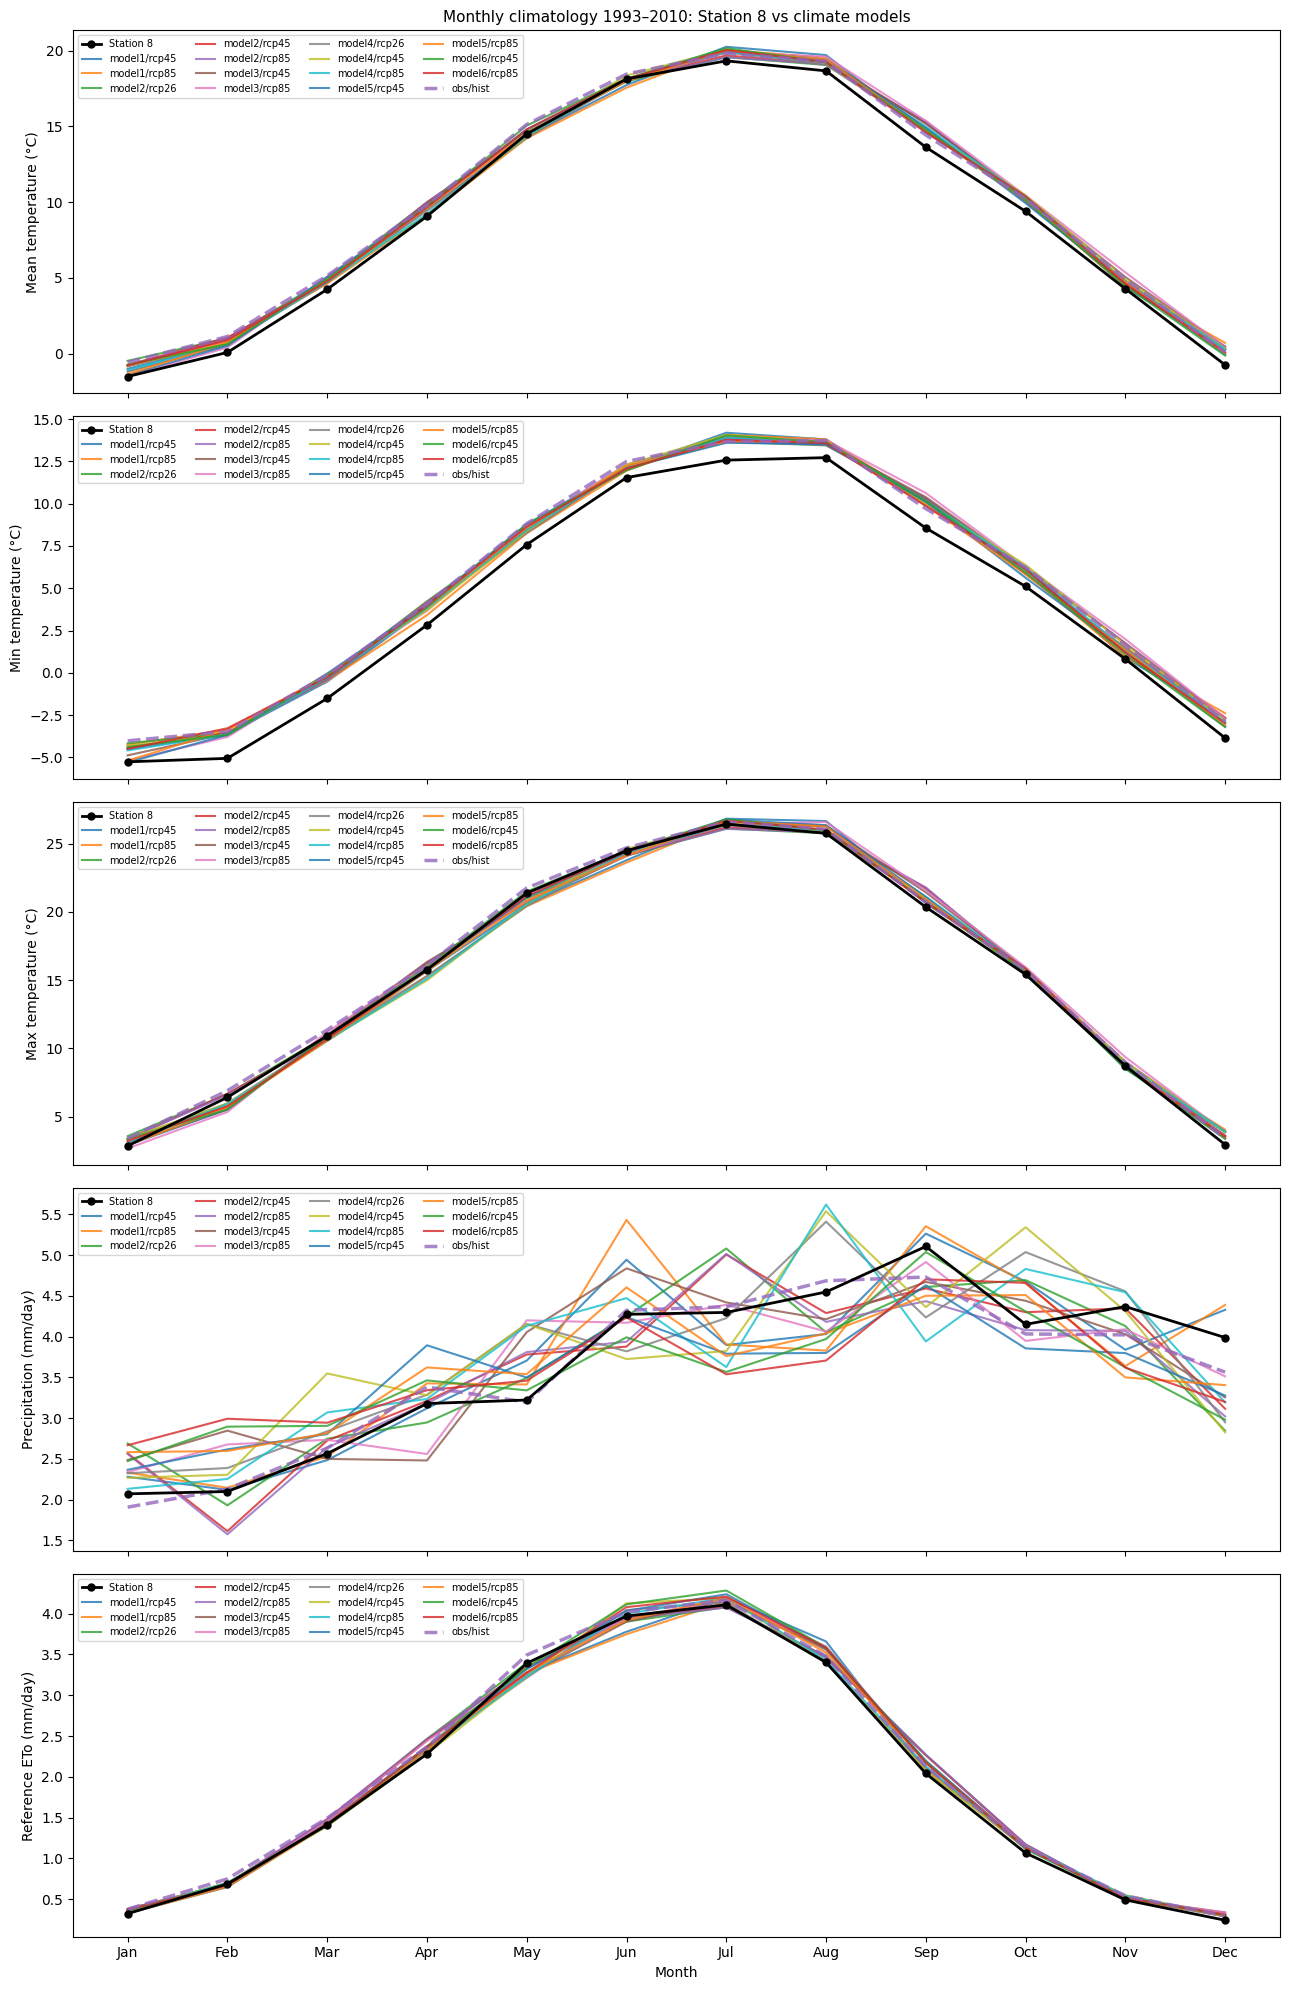

In [21]:
VAR_PAIRS = [
    ("tas",        "tpov",  "Mean temperature (°C)"),
    ("tasmin",     "tmin",  "Min temperature (°C)"),
    ("tasmax",     "tmax",  "Max temperature (°C)"),
    ("pr",         "pad",   "Precipitation (mm/day)"),
    ("evspsblpot", "etp",   "Reference ETo (mm/day)"),
]

fig, axes = plt.subplots(len(VAR_PAIRS), 1, figsize=(13, 4 * len(VAR_PAIRS)), sharex=True)

for ax, (clim_var, stat_var, ylabel) in zip(axes, VAR_PAIRS):
    # station
    ax.plot(MONTH_ABBR, station_monthly[stat_var], color="black", linewidth=2,
            marker="o", markersize=5, label=f"Station {STATION_ID}", zorder=5)

    # climate models (historical runs only)
    for (model, scenario), grp in climate_monthly.groupby(level=["model", "scenario"]):
        vals = grp.droplevel(["model", "scenario"])[clim_var].reindex(MONTH_ABBR)
        style = dict(linewidth=1.5, alpha=0.8)
        if model == "obs":
            style.update(linewidth=2.5, linestyle="--", zorder=4)
        ax.plot(MONTH_ABBR, vals, label=f"{model}/{scenario}", **style)

    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7, ncol=4, loc="upper left")

axes[0].set_title(
    f"Monthly climatology {OVERLAP_START}–{OVERLAP_END}: Station {STATION_ID} vs climate models",
    fontsize=11,
)
axes[-1].set_xlabel("Month")
plt.tight_layout()
plt.show()

In [17]:
# Bias table: annual mean of each variable (model minus station)
station_annual = {
    "tas":        station_hist["tpov"].mean(),
    "tasmin":     station_hist["tmin"].mean(),
    "tasmax":     station_hist["tmax"].mean(),
    "pr":         station_hist["pad"].mean(),
    "evspsblpot": station_hist["etp"].mean(),
}

bias_rows = []
for (model, scenario), grp in climate_hist.groupby(level=["model", "scenario"]):
    row = {"model": model, "scenario": scenario}
    for clim_var, stat_val in station_annual.items():
        row[clim_var] = grp[clim_var].mean() - stat_val
    bias_rows.append(row)

bias_df = pd.DataFrame(bias_rows).set_index(["model", "scenario"])
bias_df.columns = ["Δ tas (°C)", "Δ tasmin (°C)", "Δ tasmax (°C)", "Δ pr (mm/day)", "Δ evspsblpot (mm/day)"]
print(f"Annual mean bias (model − station {STATION_ID}), {OVERLAP_START}–{OVERLAP_END}")
display(bias_df.round(3))

Annual mean bias (model − station 8), 1993–2010


Δ tas (°C)  Δ tasmin (°C)  Δ tasmax (°C)  Δ pr (mm/day)  \
model  scenario                                                            
model1 rcp45          0.559          1.004          0.050          0.070   
       rcp85          0.505          0.999         -0.053          0.098   
model2 rcp26          0.663          1.071          0.207         -0.029   
       rcp45          0.640          1.040          0.186         -0.031   
       rcp85          0.600          0.998          0.162         -0.107   
model3 rcp45          0.652          1.071          0.178          0.028   
       rcp85          0.700          1.109          0.221         -0.024   
model4 rcp26          0.527          0.997         -0.007          0.116   
       rcp45          0.611          1.098          0.061          0.139   
       rcp85          0.544          1.013          0.019          0.102   
model5 rcp45          0.551          0.899          0.085         -0.113   
       rcp85          0.531          0.936          0.022         -0.035   
model6 rcp45          0.617          1.007          0.119         -0.115   
       rcp85          0.619          1.014          0.099         -0.072   
obs    hist           0.730          1.148          0.350         -0.076   

                 Δ evspsblpot (mm/day)  
model  scenario                         
model1 rcp45                     0.030  
       rcp85                     0.014  
model2 rcp26                     0.057  
       rcp45                     0.057  
       rcp85                     0.057  
model3 rcp45                     0.049  
       rcp85                     0.056  
model4 rcp26                     0.022  
       rcp45                     0.028  
       rcp85                     0.028  
model5 rcp45                     0.051  
       rcp85                     0.027  
model6 rcp45                     0.071  
       rcp85                     0.058  
obs    hist                      0.069